# Домашнее задание №2: Создание и оптимизация ResNet18

#### Общая цель

Поэтапная разработка кастомной ResNet18 модели для классификации Tiny ImageNet с анализом влияния различных архитектурных решений на производительность.

Датасет: Tiny ImageNet (200 классов) - выберите 10 классов самостоятельно для работы

Для работы выбрнно 5 классов в свзи с отсутвием GPU на персональном компьютере и веремнными затратами на обучение модели.

In [30]:
# загрузка библиотек
import os
import random
import numpy as np
import pandas as pd

from PIL import Image
from torch.utils.data import Dataset, DataLoader

from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import transforms, models
from tqdm import tqdm

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

torch.set_num_threads(4)  


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Часть 1: Подготовка данных

### Создание датакласса

Реализуйте собственный класс `TinyImageNetDataset`, наследующий от `torch.utils.data.Dataset`:
- Метод `__init__`: инициализация путей к данным, загрузка списка изображений и меток
- Метод `__len__`: возврат количества примеров в датасете
- Метод `__getitem__`: загрузка и возврат одного примера (изображение + метка)


In [3]:
class TinyImageNetDataset(Dataset):
    def __init__(self, root_dir, class_list, split='train', transform=None):
        """
        root_dir: путь до папки tiny-imagenet-200
        class_list: список индексов наименований классов, которые необходимо выделить 
        split: 'train', 'val' или 'test'
        transform: трансформации изображений
        """
        self.root_dir = root_dir
        self.class_list = class_list # список индексов классов в файле wnids.txt
        self.split = split
        self.transform = transform

        # загрузка классов    
        with open(os.path.join(root_dir, 'wnids.txt'), 'r') as f:
            self.class_names = [line.strip() for idx, line in enumerate(f) if idx in self.class_list] # осатвляем только выбранные классы 
        self.class_to_idx = {name: i for i, name in enumerate(self.class_names)}

        # из файла words.txt вытащим действительные имена классов
        self.real_class_names = []
        class_map = {}
        with open(os.path.join(root_dir, 'words.txt'), 'r') as f:
            for line in f:
                l = line.strip().split('\t')
                id = l[0]
                name = ' '.join(l[1:])
                class_map[id] = name
        self.real_class_names = [class_map[class_id] for class_id in self.class_names]


        self.samples = []
        if split == 'train':
            train_dir = os.path.join(root_dir, 'train')
            for cls in os.listdir(train_dir):
                if cls not in self.class_names: 
                    continue
                img_dir = os.path.join(train_dir, cls, 'images')
                if not os.path.exists(img_dir):
                    continue
                for img_name in os.listdir(img_dir):
                    img_path = os.path.join(img_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        elif split == 'val':
            val_dir = os.path.join(root_dir, 'val', 'images')
            anno_path = os.path.join(root_dir, 'val', 'val_annotations.txt')

            label_map = {}
            with open(anno_path, 'r') as f:
                for line in f:
                    img_name, cls, *_ = line.strip().split('\t')
                    label_map[img_name] = cls

            for img_name in os.listdir(val_dir):
                cls = label_map.get(img_name)
                if cls in self.class_names:
                    img_path = os.path.join(val_dir, img_name)
                    label = self.class_to_idx[cls]
                    self.samples.append((img_path, label))

        else:
            test_dir = os.path.join(root_dir, 'test', 'images')
            for img_name in os.listdir(test_dir):
                img_path = os.path.join(test_dir, img_name)
                self.samples.append((img_path, -1))  

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, label


In [4]:
train_transform = transforms.Compose([
    transforms.ToTensor(),                     
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

root = "tiny-imagenet-200/tiny-imagenet-200"

# Случайным образом выберем 5 из 200 классов
class_list = [random.randint(1, 200) for i in range(5)]

train_dataset = TinyImageNetDataset(root, class_list, split='train', transform=train_transform)
val_dataset = TinyImageNetDataset(root, class_list, split='val', transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")
print(f"Количество классов: {len(train_dataset.class_names)}")
print("Названия классов:")
for i in range(len(class_list)):
    print(f" ({i}) " + train_dataset.real_class_names[i])

Train size: 2500
Val size: 250
Количество классов: 5
Названия классов:
 (0) cliff, drop, drop-off
 (1) nail
 (2) teapot
 (3) brain coral
 (4) bucket, pail


#### Визуализация датасета

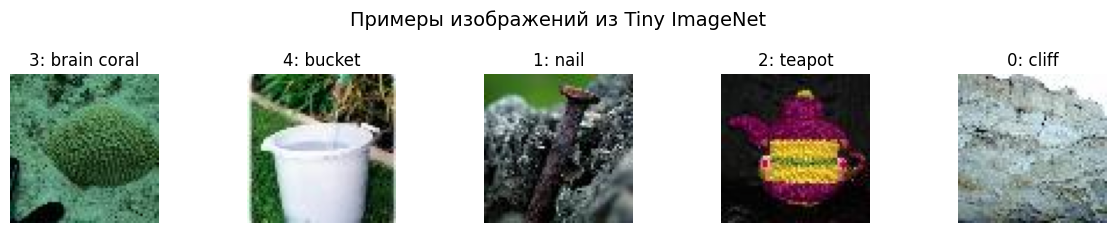

In [5]:
def denormalize(img_tensor):
    """Вернём изображение из нормализованного диапазона в [0,1]"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 1, 3)
    std = torch.tensor([0.229, 0.224, 0.225]).view(1, 1, 3)
    img = img_tensor.permute(1, 2, 0) * std + mean
    return img.clamp(0, 1)

# Выведем по пример картинки для каждого класса
samples_per_class = {}

for img_path, label in train_dataset.samples:
    if label not in samples_per_class:
        samples_per_class[label] = img_path
    if len(samples_per_class) == len(train_dataset.class_names):
        break

images = []
labels = []

for label, img_path in samples_per_class.items():
    img = Image.open(img_path).convert("RGB")
    
    if train_dataset.transform:
        img_t = train_dataset.transform(img)
    else:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                 std=[0.229, 0.224, 0.225])
        ])
        img_t = transform(img)
    
    images.append(img_t)
    labels.append(label)

images = torch.stack(images)
labels = torch.tensor(labels)

images_vis = torch.stack([denormalize(img) for img in images])

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(2, 5, i+1)
    plt.imshow(images_vis[i])
    cls_id = labels[i].item()
    cls_name = train_dataset.real_class_names[cls_id].split(', ')[0]
    plt.title(f"{cls_id}: {cls_name}")
    plt.axis('off')
plt.suptitle("Примеры изображений из Tiny ImageNet", fontsize=14)
plt.tight_layout()
plt.show()


## Часть 2: Базовая архитектура ResNet18

### 2.1. Реализация Basic Block

Создайте базовый residual блок со следующей структурой:

```
Input
  ↓
Conv2d(kernel_size=3, padding=1, stride=stride)
  ↓
BatchNorm2d
  ↓
ReLU
  ↓
Conv2d(kernel_size=3, padding=1, stride=1)
  ↓
BatchNorm2d
  ↓
  + ← Skip Connection (с возможностью downsample)
  ↓
ReLU
  ↓
Output
```

In [6]:
class BasicBlock(nn.Module):
    """
    Базовый блок ResNet с residual connection
    
    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample #skip connection


    def forward(self, x):
        # Сохраняем вход для skip connection
        identity = x

        # Первый сверточный слой + BatchNorm + ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
       
        # Второй сверточный слой + BatchNorm
        out = self.conv2(out)
        out = self.bn2(out)

        # Реализация skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        # Итоговый вывод
        out = self.relu(out + identity)

        return out

### 2.2. Реализация ResNet18

Создайте архитектуру ResNet18 со следующей структурой:

```
Input (3, 64, 64)
  ↓
Conv2d(3→64, kernel_size=7, stride=2, padding=3)  # или 3x3, stride=1 для Tiny ImageNet
  ↓
BatchNorm2d
  ↓
ReLU
  ↓
MaxPool2d(kernel_size=3, stride=2, padding=1)  # опционально для Tiny ImageNet
  ↓
Layer1: 2x Basic Block (64 channels)
  ↓
Layer2: 2x Basic Block (128 channels, stride=2 в первом блоке)
  ↓
Layer3: 2x Basic Block (256 channels, stride=2 в первом блоке)
  ↓
Layer4: 2x Basic Block (512 channels, stride=2 в первом блоке)  # ОПЦИОНАЛЬНО
  ↓
AdaptiveAvgPool2d(output_size=(1, 1))
  ↓
Flatten
  ↓
Linear(512 → 10)  # 10 классов
  ↓
Output
``` 

In [7]:
class ResNet18(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2]):
        super(ResNet18, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 256, num_blocks[2], stride=2)
        # self.layer4 = self._make_layer(BasicBlock, 512, num_blocks[3], stride=2) #опционально
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        #self.fc = nn.Linear(512, num_classes) # Если задействован layer4
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        #out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


### 2.3 Ограничения для базовой модели

- Общее количество параметров: не более 5 миллионов
- Максимальное количество каналов: до 512

In [8]:
model = ResNet18(num_classes = 5)
test_input = torch.randn(1, 3, 64, 64)

output = model(test_input)
print(f'Тестовый выход: {output}\n')

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f" Всего параметров: {total_params:,}")
print(f" Обучаемых параметров: {trainable_params:,}")

Тестовый выход: tensor([[-0.2932, -0.2136,  0.6992, -0.3675, -0.4191]],
       grad_fn=<AddmmBackward0>)

 Всего параметров: 2,778,181
 Обучаемых параметров: 2,778,181


### 2.4. Скрипт обучения

Реализуйте цикл обучения с следующими компонентами:
- Оптимизатор:
    - SGD
    - Learning rate: 0.001
- Loss function:
    - CrossEntropyLoss
- Метрики:
    - Accuracy для train/validation
    - Loss для train/validation
- Обучение:
    - Количество эпох: 20
    - Логирование метрик на каждой эпохе


In [9]:
def train_model(model, train_loader, val_loader, optimizer, criterion, device='cpu', num_epochs=20):
    """
    Функция для обучения модели на несколько эпох с вычислением train/val loss и accuracy.

    Args:
        model: модель для обучения
        train_loader: DataLoader с тренировочными данными
        val_loader: DataLoader с тестовыми данными
        optimizer: оптимизатор
        criterion: функция потерь
        device: устройство (cpu/cuda)
        num_epochs: количество эпох

    Returns:
    history = {
        train_losses: список средних потерь на train
        train_acc_list: список точностей на train
        val_losses: список средних потерь на validation
        val_acc_list: список точностей на validation
        }
    """
    model.to(device)
    
    train_losses, train_acc_list = [], []
    val_losses, val_acc_list = [], []

    best_val_acc = 0.0

    for epoch in range(num_epochs):

        # Train
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        train_iter = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)
        for inputs, labels in train_iter:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            train_iter.set_postfix(
                batch_loss=loss.item(), 
                acc=100. * correct / total
            )

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = 100. * correct / total
        train_losses.append(train_loss)
        train_acc_list.append(train_acc)

        # Validation
        model.eval()
        val_running_loss = 0.0
        correct, total = 0, 0

        val_iter = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)
        with torch.no_grad():
            for inputs, labels in val_iter:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_running_loss += loss.item() * inputs.size(0)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

                val_iter.set_postfix(
                    batch_loss=loss.item(),
                    acc=100. * correct / total
                )

        val_loss = val_running_loss / len(val_loader.dataset)
        val_acc = 100. * correct / total
        val_losses.append(val_loss)
        val_acc_list.append(val_acc)

        # Логи
        print(f'Epoch [{epoch+1}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

        # Сохраняем лучшую модель
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"\tСохранена лучшая модель с точностью {val_acc:.2f}%")

    return {
        'train_loss' : train_losses,
        'train_acc' : train_acc_list,
        'val_loss': val_losses,
        'val_acc' : val_acc_list
    }


In [10]:
model = ResNet18(num_classes = 5)
optimizer = torch.optim.SGD(model.parameters(), lr = 0.001) 
criterion = nn.CrossEntropyLoss()  
history = train_model(model, 
                      train_loader, 
                      val_loader, 
                      optimizer, 
                      criterion, 
                      device = 'cpu', 
                      num_epochs = 20)

Epoch [1/20] Train Loss: 1.4801 | Train Acc: 37.68% | Val Loss: 1.3244 | Val Acc: 44.00%
	Сохранена лучшая модель с точностью 44.00%


Epoch [2/20] Train Loss: 1.2511 | Train Acc: 50.00% | Val Loss: 1.2246 | Val Acc: 52.80%
	Сохранена лучшая модель с точностью 52.80%


Epoch [3/20] Train Loss: 1.1500 | Train Acc: 52.40% | Val Loss: 1.1946 | Val Acc: 51.20%


Epoch [4/20] Train Loss: 1.0903 | Train Acc: 56.64% | Val Loss: 1.1762 | Val Acc: 52.40%


Epoch [5/20] Train Loss: 1.0382 | Train Acc: 57.72% | Val Loss: 1.0752 | Val Acc: 61.20%
	Сохранена лучшая модель с точностью 61.20%


...

Epoch [16/20] Train Loss: 0.6700 | Train Acc: 75.64% | Val Loss: 0.8577 | Val Acc: 66.00%
	Сохранена лучшая модель с точностью 66.00%


Epoch [17/20] Train Loss: 0.6300 | Train Acc: 77.20% | Val Loss: 0.9173 | Val Acc: 64.80%


Epoch [18/20] Train Loss: 0.5794 | Train Acc: 79.24% | Val Loss: 1.1643 | Val Acc: 59.60%


Epoch [19/20] Train Loss: 0.5455 | Train Acc: 81.84% | Val Loss: 1.0404 | Val Acc: 62.80%


Epoch [20/20] Train Loss: 0.5104 | Train Acc: 82.72% | Val Loss: 0.8394 | Val Acc: 69.20%
	Сохранена лучшая модель с точностью 69.20%


### 2.5: Визуализация базовых результатов

После обучения базовой модели создайте:

График Accuracy:
- X: эпохи
- Y: accuracy
- Две линии: train и validation

График Loss:
- X: эпохи
- Y: loss
- Две линии: train и validation

In [11]:
def plot_training_history(history):

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history['train_loss'], label='Train Loss', color='blue')
    ax1.plot(history['val_loss'], label='Validation Loss', color='red')
    ax1.set_title('Training and Validation Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    ax2.plot(history['train_acc'], label='Train Accuracy', color='blue')
    ax2.plot(history['val_acc'], label='Validation Accuracy', color='red')
    ax2.set_title('Training and Validation Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

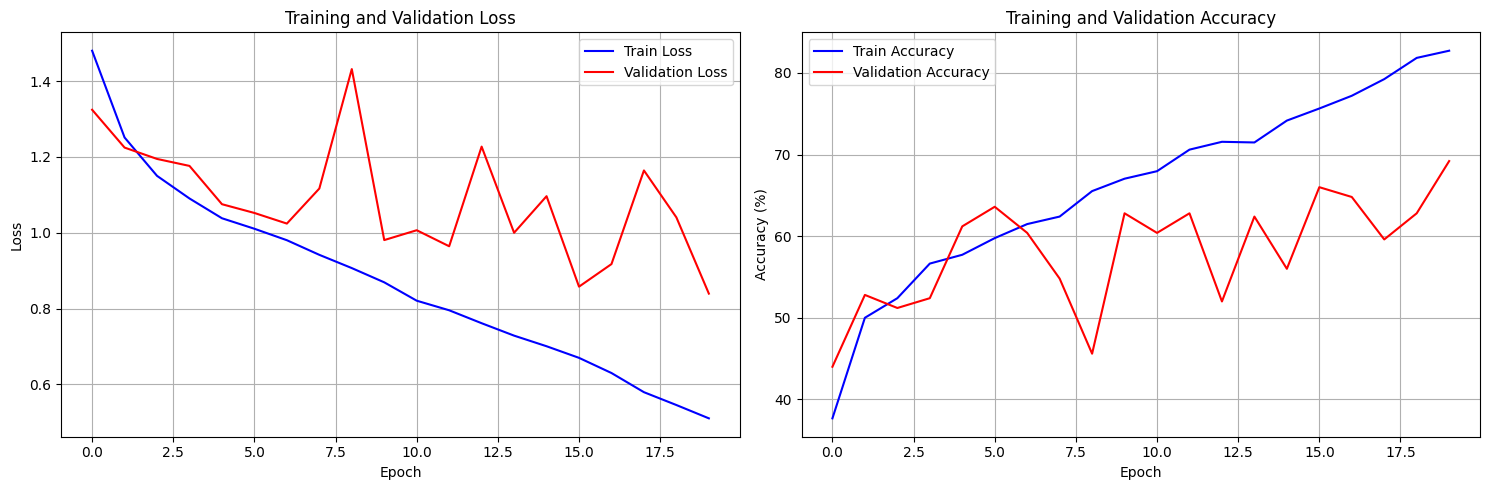

In [12]:
plot_training_history(history)

Информация о модели:
- Общее количество параметров
- Архитектура 

In [13]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Общее количество параметров модели: {total_params}")
print("Архитектура модели: ")
print(model)

Общее количество параметров модели: 2778181
Архитектура модели: 
ResNet18(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [ ]:
# Начнем заполнять датафрейм с результатами обучения моделей для пункта 4.4
def log_experiment(name, model_config, model, history):
    params = sum(p.numel() for p in model.parameters())
    return {
        "Этап": name,
        "Конфигурация": model_config,
        "Параметры": round(params, 2),
        "Train Accuracy (%)": round(history["train_acc"][-1], 2),
        "Validation Accuracy (%)": round(history["val_acc"][-1], 2)
    }

In [15]:
row = log_experiment("Baseline", '64→128→256', model, history)
results = pd.DataFrame([row])
results

,Этап,Конфигурация,Параметры,Train Accuracy (%),Validation Accuracy (%)
0,Baseline,64→128→256,2778181,82.72,69.2


## Часть 3: Поэтапная оптимизация модели

### 3.1: Оптимизация количества каналов

<b>Цель</b>: Изучение влияния количества каналов на производительность.

Эксперимент:
Создайте 2 варианта модели:
- Вариант A: 32 → 64 → 128 → 256 каналов
- Вариант B: 64 → 128 → 256 каналов (без 4-го слоя)

Обучите обе модели с теми же гиперпараметрами

Сравните:
- Количество параметров
- Validation accuracy

In [16]:
# Вариант 3.1 - A
class ResNet18_3_1_A(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2, 2]):
        super(ResNet18_3_1_A, self).__init__()
        self.in_channels = 32
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock, 32, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock, 64, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock, 128, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(BasicBlock, 256, num_blocks[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


Epoch [1/20] Train Loss: 1.5420 | Train Acc: 33.80% | Val Loss: 1.3935 | Val Acc: 40.00%
	Сохранена лучшая модель с точностью 40.00%


Epoch [2/20] Train Loss: 1.2992 | Train Acc: 47.68% | Val Loss: 1.2370 | Val Acc: 48.40%
	Сохранена лучшая модель с точностью 48.40%


Epoch [3/20] Train Loss: 1.1690 | Train Acc: 52.04% | Val Loss: 1.1618 | Val Acc: 54.00%
	Сохранена лучшая модель с точностью 54.00%


Epoch [4/20] Train Loss: 1.0893 | Train Acc: 55.12% | Val Loss: 1.1118 | Val Acc: 53.60%


Epoch [5/20] Train Loss: 1.0269 | Train Acc: 58.68% | Val Loss: 1.1657 | Val Acc: 52.80%


...

Epoch [16/20] Train Loss: 0.3681 | Train Acc: 90.36% | Val Loss: 1.1640 | Val Acc: 59.60%


Epoch [17/20] Train Loss: 0.3106 | Train Acc: 91.80% | Val Loss: 1.5112 | Val Acc: 52.00%


Epoch [18/20] Train Loss: 0.2326 | Train Acc: 94.76% | Val Loss: 1.2054 | Val Acc: 57.20%


Epoch [19/20] Train Loss: 0.2033 | Train Acc: 95.56% | Val Loss: 1.9182 | Val Acc: 54.40%


Epoch [20/20] Train Loss: 0.1816 | Train Acc: 95.84% | Val Loss: 1.7589 | Val Acc: 52.00%


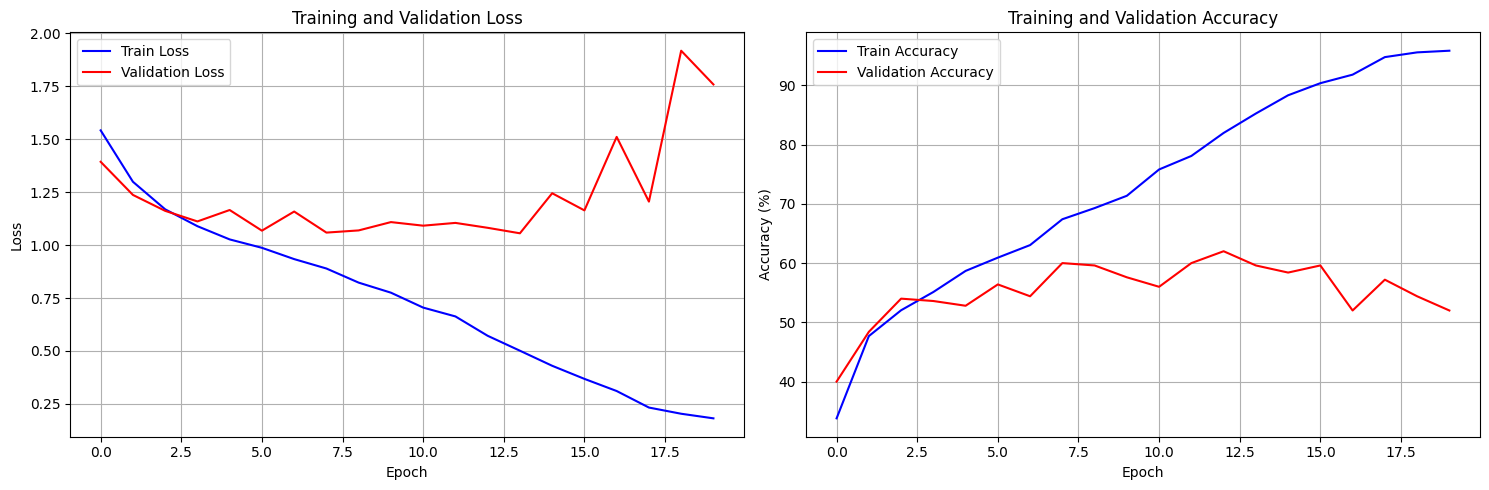

,Этап,Конфигурация,Параметры,Train Accuracy (%),Validation Accuracy (%)
0,Baseline,64→128→256,2778181,82.72,69.2
1,3.1-А,32→64→128→256,2798245,95.84,52.0


In [17]:
# Создаем модель
model_3_1A = ResNet18_3_1_A(num_classes = 5)
# Обучаем модель
history_3_1A = train_model(model = model_3_1A, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_1A.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_1A)
# Формируем таблицу для сравнения
row = log_experiment("3.1-А", '32→64→128→256', model_3_1A, history_3_1A)
results.loc[len(results)] = row
results


Вариант 3.1-B совпадает с той архитектурой, которая была получена на этапе реализации базовой модели. Следовательно, данный этап пропущен. Результаты обучения уже получены.

#### Выводы по пункту 3.1
Видим, что точность второй модели намного выше на train-е, чем на валидации. Это говорт нам о том, что модель переобучилась. Также, у второй модели большее количество параметров. Следовательно, определяемся за исходную модель, у нее и accuracy на валидации выше. 

Т.е. для дальнейшей работы будем использовать модель с <b>3 каналами 64→128→256</b>.

### 3.2: Эксперименты с количеством residual блоков

<b>Цель</b>: Изучение влияния глубины сети (количества residual блоков) на производительность.

Эксперимент:
- Используйте лучшую конфигурацию каналов из Этапа 3.1
- Создайте 3 варианта модели с разным количеством блоков в каждом слое:
    - Вариант A: [1, 1, 1, 1] - по 1 блоку в каждом слое (мелкая сеть)
    - Вариант B: [2, 2, 2, 2] - по 2 блока в каждом слое (стандартная ResNet18)
    - Вариант C: [3, 3, 3, 3] - по 3 блока в каждом слое (глубокая сеть)
- Обучите все три модели с одинаковыми гиперпараметрами

Архитектура вариантов:
- Вариант A (4 блока):  `Layer1[1 блок] → Layer2[1 блок] → Layer3[1 блок] → Layer4[1 блок]`
- Вариант B (8 блоков): `Layer1[2 блока] → Layer2[2 блока] → Layer3[2 блока] → Layer4[2 блока]`
- Вариант C (12 блоков): `Layer1[3 блока] → Layer2[3 блока] → Layer3[3 блока] → Layer4[3 блока]`

Результат:
- Сравните:
    - Количество параметров
    - Validation accuracy
    - Скорость сходимости (на каких эпохах модель достигает лучших результатов)
- Графики accuracy для всех трех вариантов на одном графике
- Анализ: какая глубина оптимальна? Есть ли переобучение у более глубоких моделей?
- Вывод: какое количество блоков работает лучше?


Epoch [1/20] Train Loss: 1.4991 | Train Acc: 34.96% | Val Loss: 1.4133 | Val Acc: 40.80%
	Сохранена лучшая модель с точностью 40.80%


Epoch [2/20] Train Loss: 1.3515 | Train Acc: 47.04% | Val Loss: 1.3165 | Val Acc: 47.20%
	Сохранена лучшая модель с точностью 47.20%


Epoch [3/20] Train Loss: 1.2702 | Train Acc: 49.84% | Val Loss: 1.2616 | Val Acc: 49.60%
	Сохранена лучшая модель с точностью 49.60%


Epoch [4/20] Train Loss: 1.2119 | Train Acc: 51.08% | Val Loss: 1.2036 | Val Acc: 53.20%
	Сохранена лучшая модель с точностью 53.20%


Epoch [5/20] Train Loss: 1.1552 | Train Acc: 53.88% | Val Loss: 1.1724 | Val Acc: 53.60%
	Сохранена лучшая модель с точностью 53.60%


...

Epoch [16/20] Train Loss: 0.9368 | Train Acc: 63.64% | Val Loss: 1.0196 | Val Acc: 63.60%


Epoch [17/20] Train Loss: 0.9188 | Train Acc: 63.04% | Val Loss: 1.0959 | Val Acc: 57.60%


Epoch [18/20] Train Loss: 0.9231 | Train Acc: 63.12% | Val Loss: 1.0524 | Val Acc: 63.20%


Epoch [19/20] Train Loss: 0.8987 | Train Acc: 64.36% | Val Loss: 0.9952 | Val Acc: 62.00%


Epoch [20/20] Train Loss: 0.8889 | Train Acc: 64.36% | Val Loss: 1.4012 | Val Acc: 44.00%


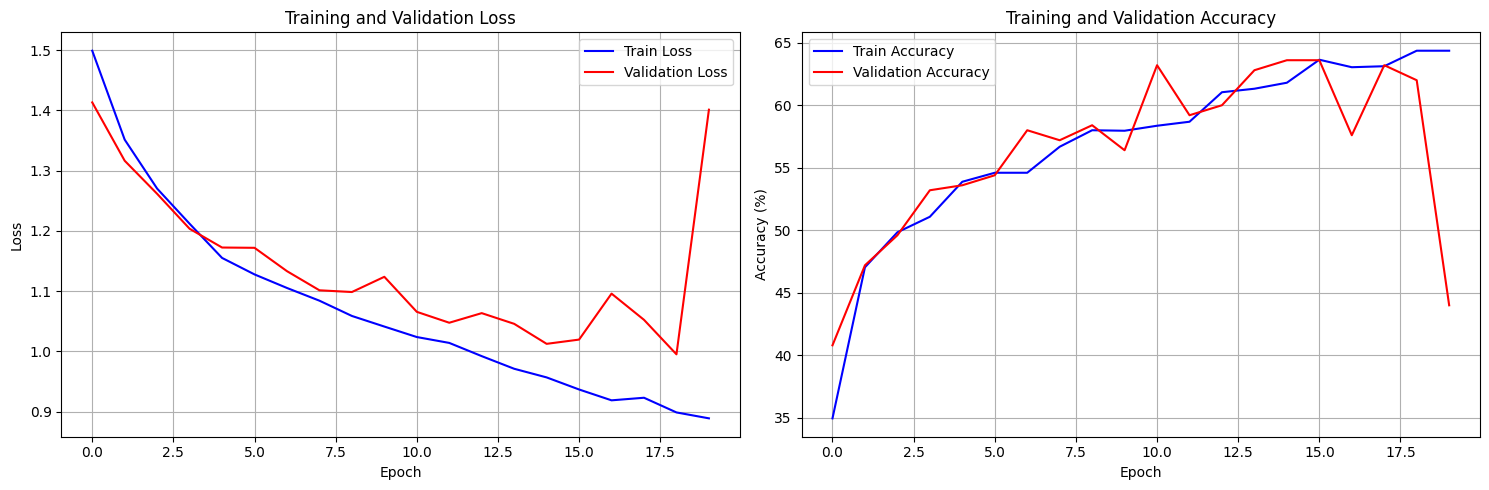

In [18]:
# Вариант 3.2-А
# Лучший результат дала исходная модель с тремя слоями, поэтому mun_blocks [1, 1, 1]
model_3_2A = ResNet18(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_3_2A = train_model(model = model_3_2A, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_2A.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_2A)
# Формируем таблицу для сравнения
row = log_experiment("3.2-А", '[1, 1, 1] блоков', model_3_2A, history_3_2A)
results.loc[len(results)] = row

Вариант 3.2-B - это и есть базовая модель, поэтому сразу переходим к варианту 3.2-C.

Epoch [1/20] Train Loss: 1.4456 | Train Acc: 40.72% | Val Loss: 1.2683 | Val Acc: 47.60%
	Сохранена лучшая модель с точностью 47.60%


Epoch [2/20] Train Loss: 1.2132 | Train Acc: 50.56% | Val Loss: 1.1494 | Val Acc: 55.20%
	Сохранена лучшая модель с точностью 55.20%


Epoch [3/20] Train Loss: 1.1076 | Train Acc: 55.48% | Val Loss: 1.1537 | Val Acc: 51.60%


Epoch [4/20] Train Loss: 1.0458 | Train Acc: 57.60% | Val Loss: 1.4700 | Val Acc: 44.80%


Epoch [5/20] Train Loss: 0.9847 | Train Acc: 60.04% | Val Loss: 1.1415 | Val Acc: 55.20%


...

Epoch [16/20] Train Loss: 0.3046 | Train Acc: 91.24% | Val Loss: 1.2351 | Val Acc: 62.00%


Epoch [17/20] Train Loss: 0.2442 | Train Acc: 93.20% | Val Loss: 1.7213 | Val Acc: 54.40%


Epoch [18/20] Train Loss: 0.1723 | Train Acc: 96.56% | Val Loss: 1.1646 | Val Acc: 65.20%
	Сохранена лучшая модель с точностью 65.20%


Epoch [19/20] Train Loss: 0.1397 | Train Acc: 96.92% | Val Loss: 1.7070 | Val Acc: 57.60%


Epoch [20/20] Train Loss: 0.1359 | Train Acc: 96.96% | Val Loss: 1.0597 | Val Acc: 63.60%


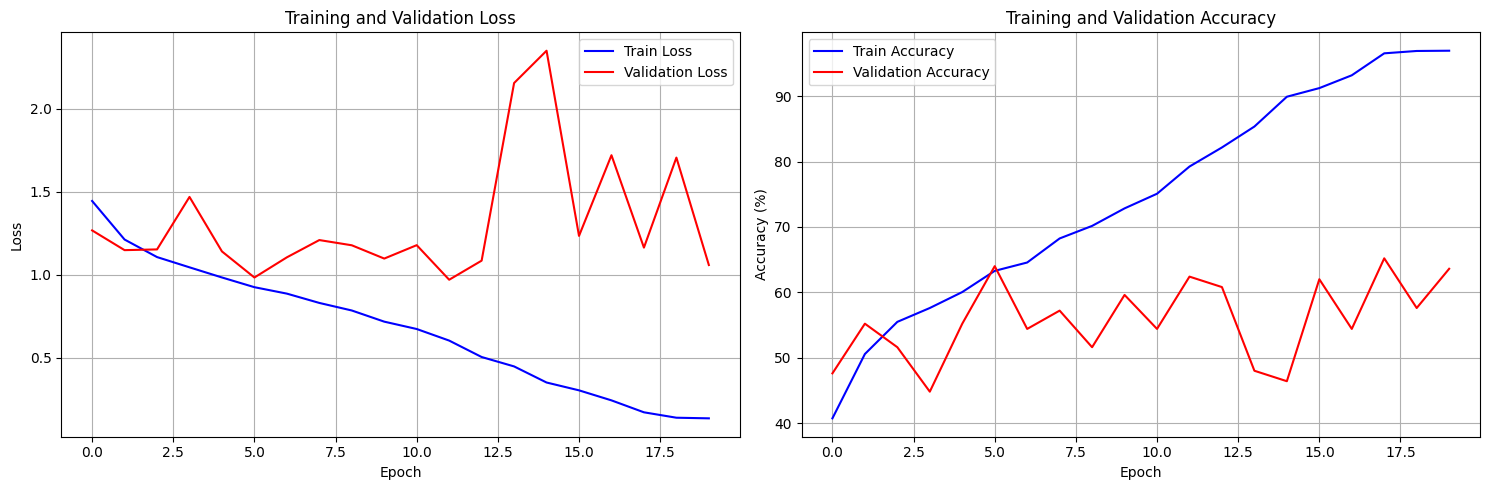

In [19]:
# Вариант 3.2-C
# Это и есть наша базовая модель
model_3_2C = ResNet18(num_classes = 5, num_blocks = [3, 3, 3])
# Обучаем модель
history_3_2C = train_model(model = model_3_2C, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_2C.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_2C)
# Формируем таблицу для сравнения
row = log_experiment("3.2-C", '[3, 3, 3] блоков', model_3_2C, history_3_2C)
results.loc[len(results)] = row

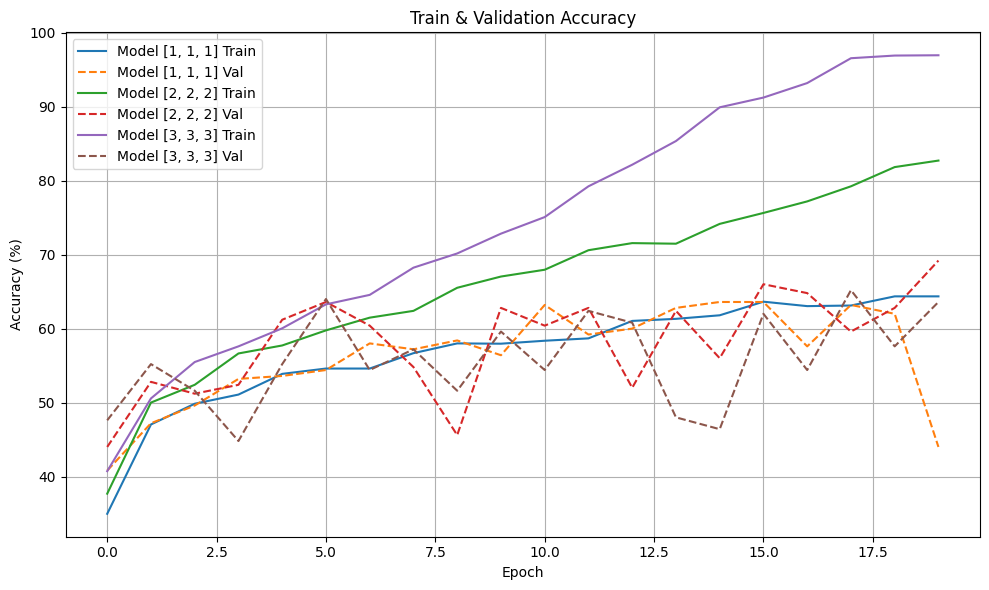

In [20]:
# Графики accyracy для всех трех моделей 
def plot_accuracies(histories, labels):
    """
    histories — список из history словарей
    labels — список названий моделей
    """

    plt.figure(figsize=(10, 6))

    for history, label in zip(histories, labels):
        plt.plot(history['train_acc'], label=f'{label} Train')
        plt.plot(history['val_acc'], label=f'{label} Val', linestyle='--')

    plt.title('Train & Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_accuracies(
    histories=[history_3_2A, history, history_3_2C],
    labels=["Model [1, 1, 1]", "Model [2, 2, 2]", "Model [3, 3, 3]"]
)


In [21]:
print("Таблица с результатами:")
results

Таблица с результатами:


,Этап,Конфигурация,Параметры,Train Accuracy (%),Validation Accuracy (%)
0,Baseline,64→128→256,2778181,82.72,69.2
1,3.1-А,32→64→128→256,2798245,95.84,52.0
2,3.2-А,"[1, 1, 1] блоков",1227205,64.36,44.0
3,3.2-C,"[3, 3, 3] блоков",4329157,96.96,63.6


#### Выводы по пункту 3.2

На основе полученных результатов видим, что оптимальной является глубина [1, 1, 1], т.к. в данном случае accuracy на train-e и валидации близки друг другу (на поседней эпохе accuracy упала, но тем не менее на других эпохах они близки). С увеличением глибины разница в значениях метрики на двух множествах увеличивается. Иными словами, более глубокие модели склоны к переобучению.

Анализируя значение метрики по эпохам видим, что наиболее стабильно себя ведет модель глубиной 1. У других двух моделей, особенно в модели глубины 3, значения метрики существенно отличаются по эпохам. Модель глубиной 1 наибольшие значения accuracy достигает на 15-ой эпохе. Модель глубиной 2 - на последней, а модель глубиной 3 - на 6-ой.

Дальше продолжим работу с моделью <b>глубиной 1</b>.

### 3.3: Эксперименты с функциями активации

<b>Цель</b>: Исследование влияния различных активаций на обучение.

Модификация модели: Замените ReLU на другие функции активации:

Эксперимент:
- Используйте лучшую конфигурацию из Этапа 3.2 (каналы + количество блоков)
- Обучите модели с разными активациями:
    - Вариант A: ReLU (baseline)
    - Вариант B: LeakyReLU
    - Вариант C: ELU
    - Вариант D: GELU

Важно: Используйте inplace=True где возможно для экономии памяти

Результат:
- Сравнение скорости сходимости (accuracy на каждой эпохе)
- Финальная validation accuracy
- Вывод: какая активация работает лучше?

Вариант 3.3-А - это и есть исходная модель. Поэтому перейдем к испольованию других функций активаций. 

In [22]:
# Вариант 3.3-B 
# LeakyReLU

class BasicBlock_3_3B(nn.Module):
    """
    Базовый блок ResNet с residual connection
    
    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.downsample = downsample #skip connection


    def forward(self, x):
        # Сохраняем вход для skip connection
        identity = x

        # Первый сверточный слой + BatchNorm + ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu(out)
       
        # Второй сверточный слой + BatchNorm
        out = self.conv2(out)
        out = self.bn2(out)

        # Реализация skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        # Итоговый вывод
        out = self.leakyrelu(out + identity)

        return out

class ResNet18_3_3B(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2]):
        super(ResNet18_3_3B, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock_3_3B, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock_3_3B, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock_3_3B, 256, num_blocks[2], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


Epoch [1/20] Train Loss: 1.5103 | Train Acc: 36.04% | Val Loss: 1.4011 | Val Acc: 46.00%
	Сохранена лучшая модель с точностью 46.00%


Epoch [2/20] Train Loss: 1.3251 | Train Acc: 49.60% | Val Loss: 1.2821 | Val Acc: 51.60%
	Сохранена лучшая модель с точностью 51.60%


Epoch [3/20] Train Loss: 1.2428 | Train Acc: 51.16% | Val Loss: 1.2282 | Val Acc: 54.80%
	Сохранена лучшая модель с точностью 54.80%


Epoch [4/20] Train Loss: 1.1783 | Train Acc: 54.00% | Val Loss: 1.1816 | Val Acc: 54.40%


Epoch [5/20] Train Loss: 1.1467 | Train Acc: 54.20% | Val Loss: 1.1343 | Val Acc: 56.40%
	Сохранена лучшая модель с точностью 56.40%


...

Epoch [16/20] Train Loss: 0.9291 | Train Acc: 63.48% | Val Loss: 1.1485 | Val Acc: 54.00%


Epoch [17/20] Train Loss: 0.9125 | Train Acc: 64.84% | Val Loss: 1.0264 | Val Acc: 63.20%
	Сохранена лучшая модель с точностью 63.20%


Epoch [18/20] Train Loss: 0.8919 | Train Acc: 65.16% | Val Loss: 1.0304 | Val Acc: 61.20%


Epoch [19/20] Train Loss: 0.8805 | Train Acc: 66.12% | Val Loss: 0.9658 | Val Acc: 62.00%


Epoch [20/20] Train Loss: 0.8612 | Train Acc: 65.96% | Val Loss: 1.0503 | Val Acc: 60.80%


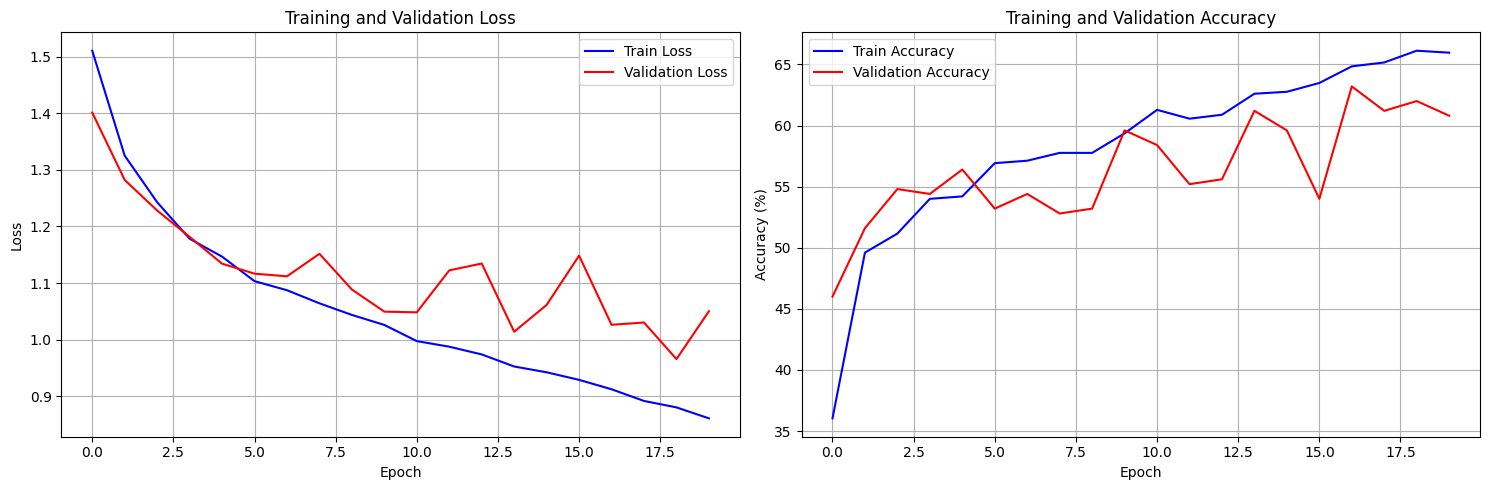

In [23]:
model_3_3B = ResNet18_3_3B(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_3_3B = train_model(model = model_3_3B, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_3B.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_3B)
# Формируем таблицу для сравнения
row = log_experiment("3.3-B", 'LeakyReLU', model_3_3B, history_3_3B)
results.loc[len(results)] = row

In [24]:
# Вариант 3.3-C 
# ELU

class BasicBlock_3_3C(nn.Module):
    """
    Базовый блок ResNet с residual connection
    
    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.elu = nn.ELU(inplace=True)
        self.downsample = downsample #skip connection


    def forward(self, x):
        # Сохраняем вход для skip connection
        identity = x

        # Первый сверточный слой + BatchNorm + ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.elu(out)
       
        # Второй сверточный слой + BatchNorm
        out = self.conv2(out)
        out = self.bn2(out)

        # Реализация skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        # Итоговый вывод
        out = self.elu(out + identity)

        return out

class ResNet18_3_3C(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2]):
        super(ResNet18_3_3C, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.elu = nn.ELU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock_3_3C, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock_3_3C, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock_3_3C, 256, num_blocks[2], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.elu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


Epoch [1/20] Train Loss: 1.4039 | Train Acc: 41.92% | Val Loss: 1.3143 | Val Acc: 45.60%
	Сохранена лучшая модель с точностью 45.60%


Epoch [2/20] Train Loss: 1.2690 | Train Acc: 48.04% | Val Loss: 1.2135 | Val Acc: 50.80%
	Сохранена лучшая модель с точностью 50.80%


Epoch [3/20] Train Loss: 1.2019 | Train Acc: 52.12% | Val Loss: 1.1622 | Val Acc: 52.00%
	Сохранена лучшая модель с точностью 52.00%


Epoch [4/20] Train Loss: 1.1456 | Train Acc: 55.16% | Val Loss: 1.1237 | Val Acc: 52.00%


Epoch [5/20] Train Loss: 1.1050 | Train Acc: 55.52% | Val Loss: 1.1216 | Val Acc: 55.60%
	Сохранена лучшая модель с точностью 55.60%


...

Epoch [16/20] Train Loss: 0.9240 | Train Acc: 63.44% | Val Loss: 0.9763 | Val Acc: 62.80%
	Сохранена лучшая модель с точностью 62.80%


Epoch [17/20] Train Loss: 0.9243 | Train Acc: 62.60% | Val Loss: 1.0660 | Val Acc: 55.60%


Epoch [18/20] Train Loss: 0.9166 | Train Acc: 63.32% | Val Loss: 1.0681 | Val Acc: 55.60%


Epoch [19/20] Train Loss: 0.8893 | Train Acc: 64.76% | Val Loss: 0.9380 | Val Acc: 62.80%


Epoch [20/20] Train Loss: 0.8864 | Train Acc: 65.36% | Val Loss: 0.9777 | Val Acc: 61.20%


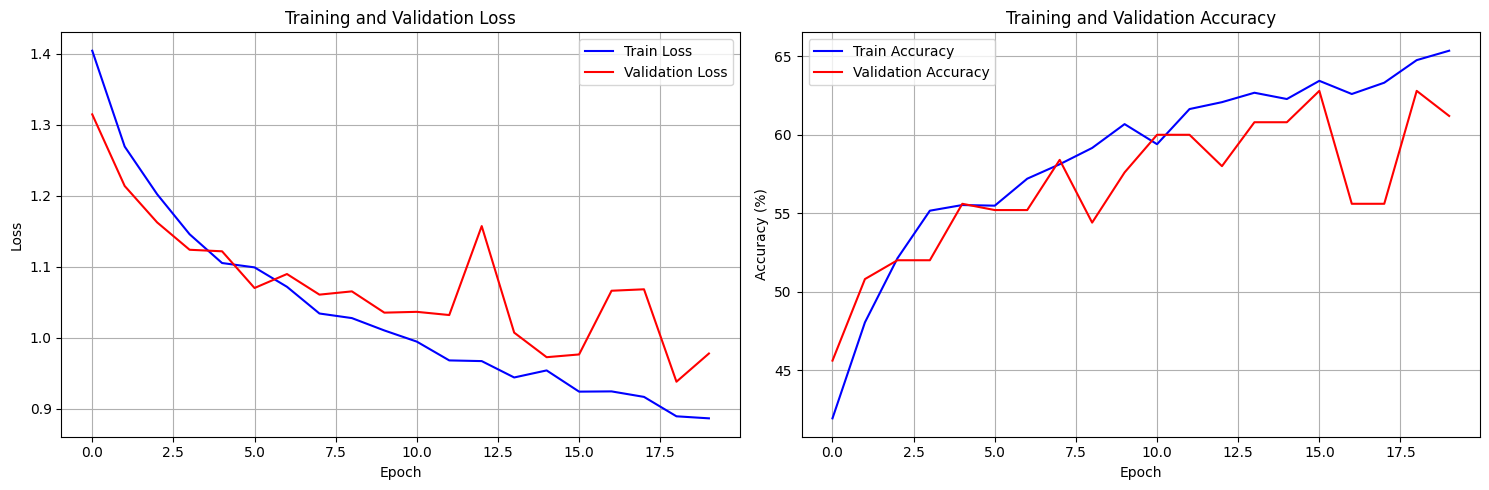

In [25]:
model_3_3C = ResNet18_3_3C(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_3_3C = train_model(model = model_3_3C, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_3C.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_3C)
# Формируем таблицу для сравнения
row = log_experiment("3.3-C", 'ELU', model_3_3C, history_3_3C)
results.loc[len(results)] = row

In [26]:
# Вариант 3.3-D 
# GELU

class BasicBlock_3_3D(nn.Module):
    """
    Базовый блок ResNet с residual connection
    
    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.gelu = nn.GELU()
        self.downsample = downsample #skip connection


    def forward(self, x):
        # Сохраняем вход для skip connection
        identity = x

        # Первый сверточный слой + BatchNorm + ReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.gelu(out)
       
        # Второй сверточный слой + BatchNorm
        out = self.conv2(out)
        out = self.bn2(out)

        # Реализация skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        # Итоговый вывод
        out = self.gelu(out + identity)

        return out

class ResNet18_3_3D(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2]):
        super(ResNet18_3_3D, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.gelu = nn.GELU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock_3_3D, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock_3_3D, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock_3_3D, 256, num_blocks[2], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.gelu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out


Epoch 1/20 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch [1/20] Train Loss: 1.5114 | Train Acc: 36.24% | Val Loss: 1.4056 | Val Acc: 44.40%
	Сохранена лучшая модель с точностью 44.40%


Epoch [2/20] Train Loss: 1.3523 | Train Acc: 47.12% | Val Loss: 1.2973 | Val Acc: 52.40%
	Сохранена лучшая модель с точностью 52.40%


Epoch [3/20] Train Loss: 1.2707 | Train Acc: 51.60% | Val Loss: 1.2433 | Val Acc: 51.20%


Epoch [4/20] Train Loss: 1.2107 | Train Acc: 52.76% | Val Loss: 1.1809 | Val Acc: 54.00%
	Сохранена лучшая модель с точностью 54.00%


...

Epoch [16/20] Train Loss: 0.9254 | Train Acc: 63.16% | Val Loss: 0.9944 | Val Acc: 61.60%


Epoch [17/20] Train Loss: 0.9049 | Train Acc: 65.60% | Val Loss: 1.0120 | Val Acc: 57.60%


Epoch [18/20] Train Loss: 0.8859 | Train Acc: 66.32% | Val Loss: 0.9853 | Val Acc: 64.00%
	Сохранена лучшая модель с точностью 64.00%


Epoch [19/20] Train Loss: 0.8795 | Train Acc: 66.08% | Val Loss: 0.9677 | Val Acc: 64.00%


Epoch [20/20] Train Loss: 0.8668 | Train Acc: 66.08% | Val Loss: 0.9687 | Val Acc: 62.40%


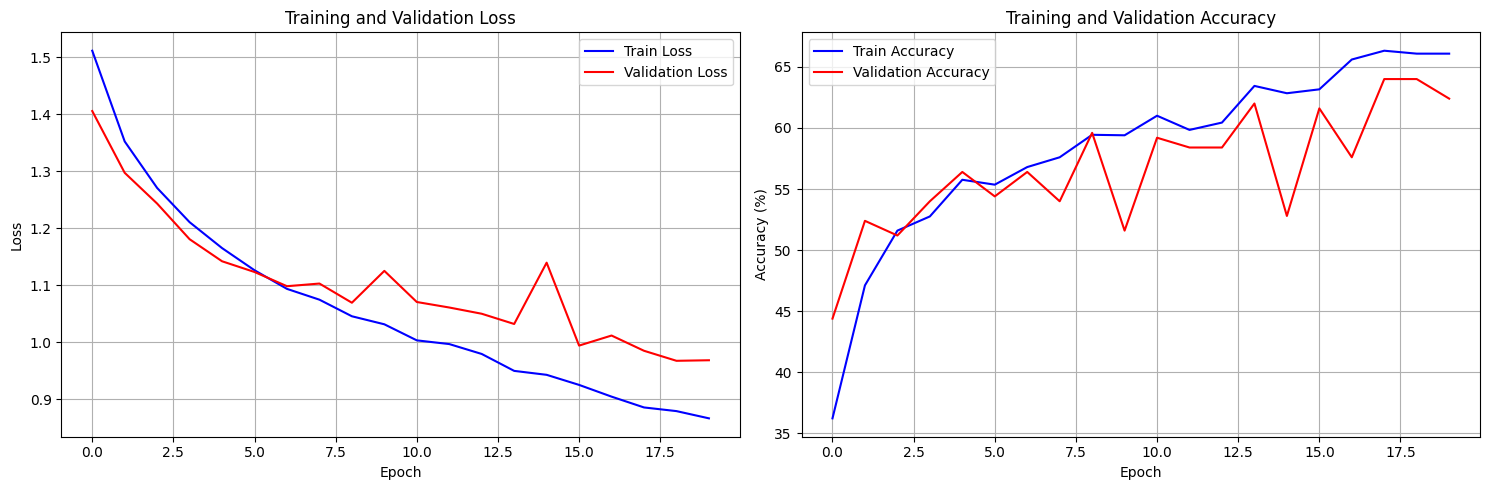

In [27]:
model_3_3D = ResNet18_3_3D(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_3_3D = train_model(model = model_3_3D, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_3_3D.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 20)
# Графики accuracy и loss 
plot_training_history(history_3_3D)
# Формируем таблицу для сравнения
row = log_experiment("3.3-D", 'GELU', model_3_3D, history_3_3D)
results.loc[len(results)] = row

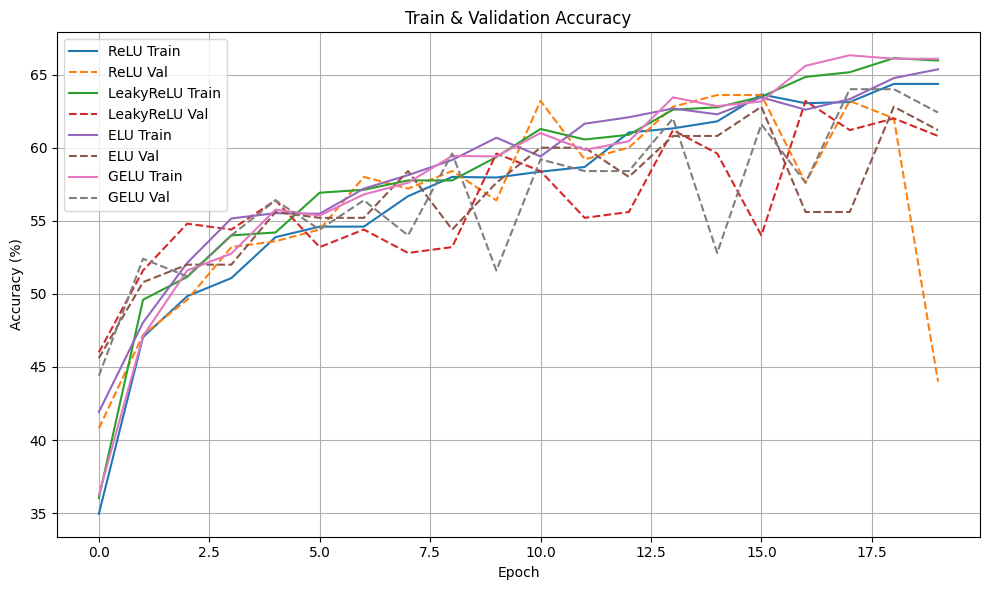

In [28]:
# Сравнение accuracy на моделях с различными функциями активации
plot_accuracies(
    histories=[history_3_2A, history_3_3B, history_3_3C, history_3_3D],
    labels=["ReLU", "LeakyReLU", "ELU", "GELU"]
)

In [38]:
print("Таблица с результатами:")
results

Таблица с результатами:


,Этап,Конфигурация,Параметры,Train Accuracy (%),Validation Accuracy (%)
0,Baseline,64→128→256,2778181,82.88,68.4
1,3.1-А,32→64→128→256,2798245,97.88,45.6
2,3.2-А,"[1, 1, 1] блоков",1227205,66.24,65.2
3,3.2-C,"[3, 3, 3] блоков",4329157,97.08,60.4
4,3.3-B,LeakyReLU,1227205,66.32,66.8
5,3.3-C,ELU,1227205,65.52,58.8
6,3.3-D,GELU,1227205,65.96,59.2


#### Выводи по пункту 3.3

Наибольшую accuracy достигает модель использующая функцию активации ReLU. Своего мксимального значения она достигает на 15-ой эпохе. Модель использующая функцию активации LeakyReLU достигает примерно одинаковую точность на валидации и на train-e. У осатльных моделй точность немного ниже, но в целом стабильная к концу обучения.

Если смотреть на validation accuracy  к концу обучения лучшей оказывается модель, использующая функцию <b>LeakyReLU</b> (66.8%), затем следует ReLU (65.2%), GELU (59.2%), a за ней функция ELU (58.8%). 


## Часть 4: Финальная модель и тестирование

### 4.1: Создание финальной модели

На основе всех экспериментов:
- Выберите лучшую конфигурацию каналов (из Этапа 3.1)
- Выберите оптимальное количество residual блоков (из Этапа 3.2) - объясните, почему выбрали именно это количество
- Выберите лучшую функцию активации (из Этапа 3.3)
- Обучите финальную модель на 30-40 эпох с выбранными параметрами


На основе проделанных экспериментов лучшая модель будет иметь следующую архитектуру:
- этап 3.1: 3 слоя 64→128→256
- этап 3.2: глубина [1, 1, 1]
- этап 3.3: функция активации LeakyReLU

In [6]:
# Финальный вариант
# LeakyReLU

class BasicBlock_Final(nn.Module):
    """
    Базовый блок ResNet с residual connection
    
    Args:
        in_channels (int): количество входных каналов
        out_channels (int): количество выходных каналов
        stride (int): шаг свертки (по умолчанию 1)
        downsample (nn.Module): слой для изменения размерности (если нужно)
    """
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.downsample = downsample #skip connection


    def forward(self, x):
        # Сохраняем вход для skip connection
        identity = x

        # Первый сверточный слой + BatchNorm + LeakyReLU
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu(out)
       
        # Второй сверточный слой + BatchNorm
        out = self.conv2(out)
        out = self.bn2(out)

        # Реализация skip connection
        if self.downsample is not None:
            identity = self.downsample(x)

        # Итоговый вывод
        out = self.leakyrelu(out + identity)

        return out

class ResNet18_Final(nn.Module):
    def __init__(self, num_classes = 5, num_blocks = [2, 2, 2]):
        super(ResNet18_Final, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.leakyrelu = nn.LeakyReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.layer1 = self._make_layer(BasicBlock_Final, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(BasicBlock_Final, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(BasicBlock_Final, 256, num_blocks[2], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None

        # Если stride != 1 или меняется число каналов, тогда нужен skip connection
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))

        self.in_channels = out_channels

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)


    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.leakyrelu(out)
        out = self.maxpool(out)
        
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

Epoch [1/40] Train Loss: 1.4948 | Train Acc: 37.16% | Val Loss: 1.3799 | Val Acc: 47.20%
	Сохранена лучшая модель с точностью 47.20%


Epoch [2/40] Train Loss: 1.3292 | Train Acc: 48.32% | Val Loss: 1.2784 | Val Acc: 49.60%
	Сохранена лучшая модель с точностью 49.60%


Epoch [3/40] Train Loss: 1.2451 | Train Acc: 50.76% | Val Loss: 1.2249 | Val Acc: 50.80%
	Сохранена лучшая модель с точностью 50.80%


Epoch [4/40] Train Loss: 1.1874 | Train Acc: 53.56% | Val Loss: 1.1872 | Val Acc: 50.40%


Epoch [5/40] Train Loss: 1.1542 | Train Acc: 54.16% | Val Loss: 1.1546 | Val Acc: 54.00%
	Сохранена лучшая модель с точностью 54.00%


...

Epoch [36/40] Train Loss: 0.7018 | Train Acc: 74.00% | Val Loss: 1.0641 | Val Acc: 58.40%


Epoch [37/40] Train Loss: 0.6804 | Train Acc: 75.12% | Val Loss: 1.4441 | Val Acc: 50.00%


Epoch [38/40] Train Loss: 0.6802 | Train Acc: 75.08% | Val Loss: 0.8886 | Val Acc: 63.60%


Epoch [39/40] Train Loss: 0.6600 | Train Acc: 75.32% | Val Loss: 0.9257 | Val Acc: 65.20%


Epoch [40/40] Train Loss: 0.6635 | Train Acc: 74.96% | Val Loss: 0.8576 | Val Acc: 69.20%
	Сохранена лучшая модель с точностью 69.20%


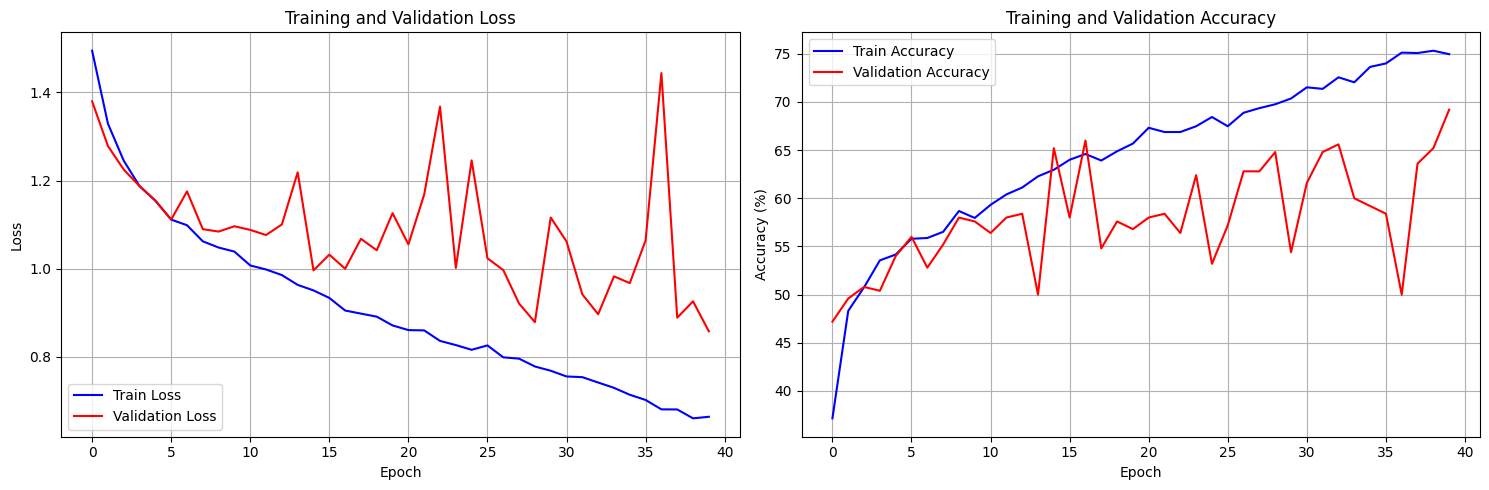

In [37]:
model_Final = ResNet18_Final(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_Final = train_model(model = model_Final, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.SGD(model_Final.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 40)
# Графики accuracy и loss 
plot_training_history(history_Final)
# Формируем таблицу для сравнения
row = log_experiment("Final", 'Лучшая конфигурация', model_Final, history_Final)
results.loc[len(results)] = row

Epoch [1/40] Train Loss: 1.3132 | Train Acc: 44.72% | Val Loss: 1.2524 | Val Acc: 49.20%
	Сохранена лучшая модель с точностью 49.20%


Epoch [2/40] Train Loss: 1.1581 | Train Acc: 51.64% | Val Loss: 1.1424 | Val Acc: 50.40%
	Сохранена лучшая модель с точностью 50.40%


Epoch [3/40] Train Loss: 1.0890 | Train Acc: 55.20% | Val Loss: 1.0373 | Val Acc: 58.80%
	Сохранена лучшая модель с точностью 58.80%


Epoch [4/40] Train Loss: 1.0181 | Train Acc: 59.12% | Val Loss: 1.2194 | Val Acc: 54.00%


Epoch [5/40] Train Loss: 0.9685 | Train Acc: 60.32% | Val Loss: 0.9513 | Val Acc: 62.80%
	Сохранена лучшая модель с точностью 62.80%


...

Epoch [36/40] Train Loss: 0.0348 | Train Acc: 99.08% | Val Loss: 1.6665 | Val Acc: 66.40%


Epoch [37/40] Train Loss: 0.0389 | Train Acc: 98.48% | Val Loss: 2.3222 | Val Acc: 61.20%


Epoch [38/40] Train Loss: 0.1452 | Train Acc: 94.64% | Val Loss: 1.6922 | Val Acc: 66.40%


Epoch [39/40] Train Loss: 0.1140 | Train Acc: 96.08% | Val Loss: 1.5948 | Val Acc: 66.00%


Epoch [40/40] Train Loss: 0.0577 | Train Acc: 98.04% | Val Loss: 1.6237 | Val Acc: 67.60%


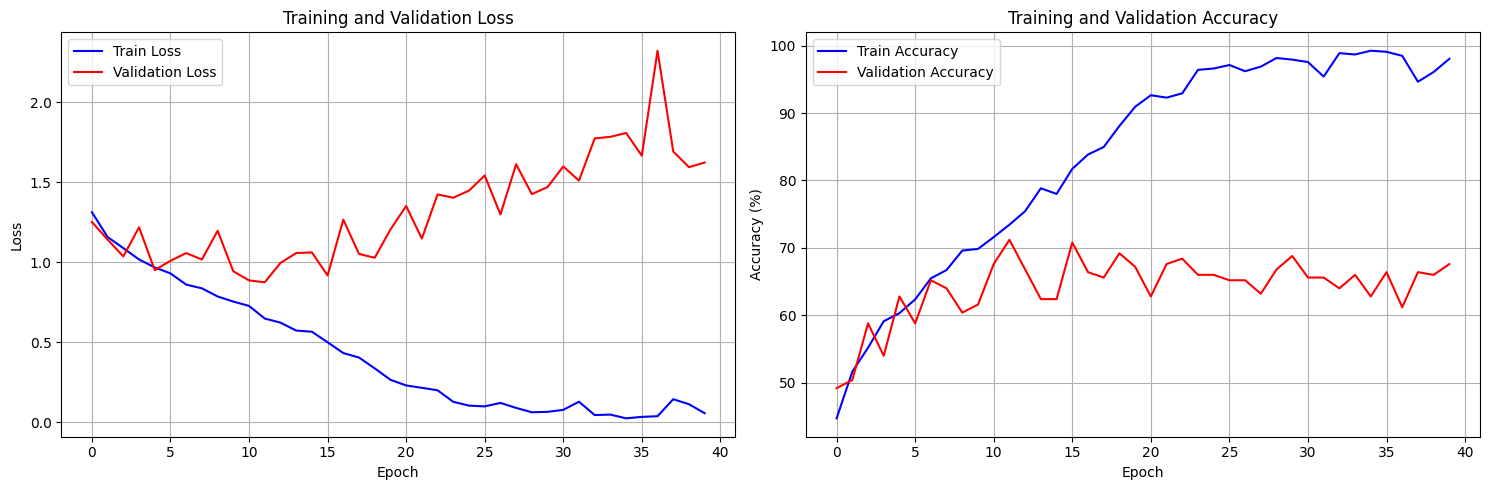

In [39]:
# Дополнительно посмотрим на лучшую конфигурацию с измененым оптимизатором на AdamW
model_Final_AdamW = ResNet18_Final(num_classes = 5, num_blocks = [1, 1, 1])
# Обучаем модель
history_Final_AdamW = train_model(model = model_Final_AdamW, 
                      train_loader = train_loader, 
                      val_loader = val_loader, 
                      optimizer = torch.optim.AdamW(model_Final_AdamW.parameters(), lr = 0.001) , 
                      criterion = nn.CrossEntropyLoss(), 
                      device = 'cpu', 
                      num_epochs = 40)
# Графики accuracy и loss 
plot_training_history(history_Final_AdamW)
# Формируем таблицу для сравнения
row = log_experiment("Final_AdamW", 'Лучшая конфигурация + AdamW', model_Final_AdamW, history_Final_AdamW)
results.loc[len(results)] = row

Видим, что в случае использования оптимзатора AdamW модель переобучилясь. Следовательно, определяемся за вариант с оптимизатором SGD. 

### 4.2: Тестирование на test set

После обучения финальной модели:
- Загрузите лучшую модель (сохраненную по validation accuracy)
- Оцените на test set:
    - Accuracy
    - Precision, Recall, F1-score для каждого класса
    - Confusion Matrix

In [44]:
# Загрузка лучшей модели
model_final = ResNet18_Final(num_classes = 5, num_blocks = [1, 1, 1])
model_final.load_state_dict(torch.load('best_model_final_SGD.pth', weights_only=True, map_location = 'cpu'))

<All keys matched successfully>

In [58]:
# Прогон модели по тестовому набору сделаем на валидации, т.к. тестовый датасет нет имеет меток
all_labels = []
all_preds = []

model_final.eval()

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Evaluating", unit="batch"):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_final(images)
        preds = torch.argmax(outputs, dim=1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

all_labels = np.concatenate(all_labels)
all_preds = np.concatenate(all_preds)


# Оценим метрики

# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Получим Precision, Recall, F1-score по классам изпользуя classification_report
report = classification_report(all_labels, all_preds)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Вывод результатов
print(f"Accuracy: {accuracy:.2f}")
print("Precision, Recall, F1-score по классам:")
print(report)

Evaluating: 100%|██████████| 16/16 [00:02<00:00,  7.48batch/s]

Accuracy: 0.63
Precision, Recall, F1-score по классам:
              precision    recall  f1-score   support

           0       0.55      0.84      0.67        50
           1       0.57      0.50      0.53        50
           2       0.70      0.38      0.49        50
           3       0.78      0.90      0.83        50
           4       0.58      0.52      0.55        50

    accuracy                           0.63       250
   macro avg       0.64      0.63      0.61       250
weighted avg       0.64      0.63      0.61       250



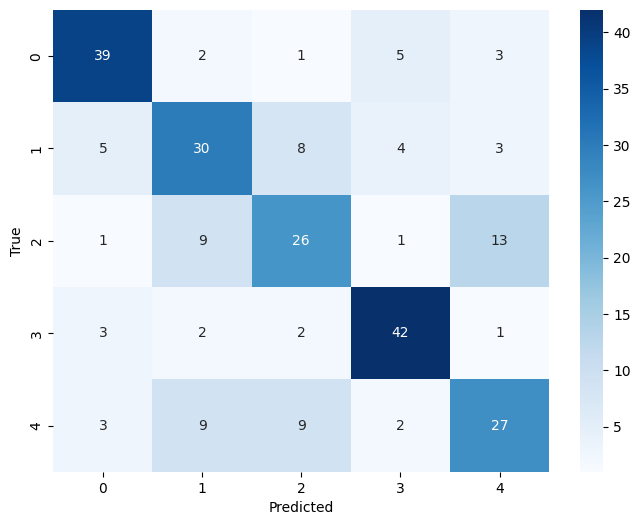

In [46]:
# Confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

### 4.3: Визуальный анализ

Создайте визуализацию с 10 случайными примерами из test set:

`[Изображение 1] | Истинный класс: cat    | Предсказание: cat`

`[Изображение 2] | Истинный класс: dog    | Предсказание: wolf`

`...`

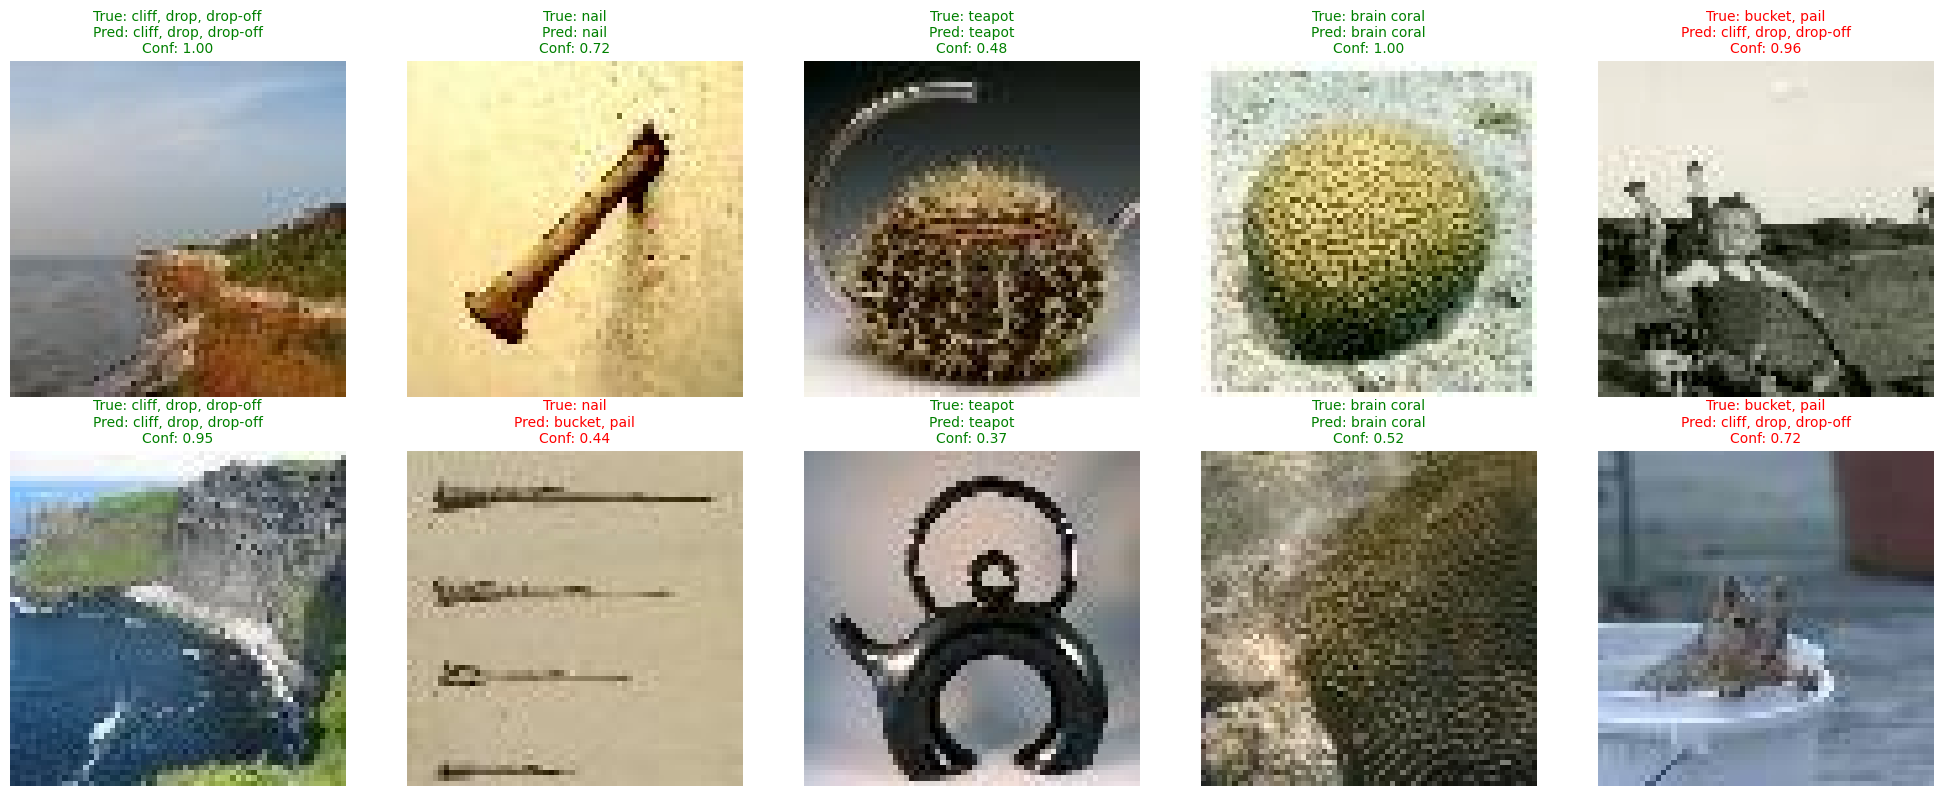

In [80]:
indices_by_class = defaultdict(list)

for idx in range(len(val_dataset)):
    _, label = val_dataset[idx]
    indices_by_class[label].append(idx)

# Выбираем случайные 2 изображения для каждого класса
samples_per_class = {
    cls: random.sample(idxs, 2)
    for cls, idxs in indices_by_class.items()
    if len(idxs) >= 2
}

sorted_classes = sorted(samples_per_class.keys())
num_classes = len(sorted_classes)

# Визуализация
plt.figure(figsize=(4 * num_classes, 8))

for col, cls in enumerate(sorted_classes):
    for row in range(2):
        idx = samples_per_class[cls][row]
        image, label = val_dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():
            output = model_final(input_tensor)
            probs = F.softmax(output, dim=1)[0]
            pred = torch.argmax(output, dim=1).item()
            confidence = probs[pred].item()

        true_class = val_dataset.real_class_names[label]
        pred_class = val_dataset.real_class_names[pred]

        img_np = denormalize(image).cpu().numpy()

        plt.subplot(2, num_classes, row * num_classes + col + 1)
        plt.imshow(img_np)
        plt.axis("off")

        color = "green" if pred == label else "red"

        
        plt.title(
            f"True: {true_class}\n"
            f"Pred: {pred_class}\n"
            f"Conf: {confidence:.2f}",
            color=color,
            fontsize=10
        )

plt.tight_layout()
plt.show()

### 4.4: Сравнительная таблица всех экспериментов

Создайте итоговую таблицу со всеми результатами.

Анализ:
- Какая конфигурация показала лучший результат?
- Есть ли признаки переобучения (большая разница между train и val)?

In [40]:
print("Таблица сравнения")
results

Таблица сравнения


,Этап,Конфигурация,Параметры,Train Accuracy (%),Validation Accuracy (%)
0,Baseline,64→128→256,2778181,82.72,69.2
1,3.1-А,32→64→128→256,2798245,95.84,52.0
2,3.2-А,"[1, 1, 1] блоков",1227205,64.36,44.0
3,3.2-C,"[3, 3, 3] блоков",4329157,96.96,63.6
4,3.3-B,LeakyReLU,1227205,65.96,60.8
5,3.3-C,ELU,1227205,65.36,61.2
6,3.3-D,GELU,1227205,66.08,62.4
7,Final,Лучшая конфигурация,1227205,74.96,69.2
8,Final_AdamW,Лучшая конфигурация + AdamW,1227205,98.04,67.6


#### Выводы

Лучшие результаты показала итоговая конфигурация ResNet18: с 3 каналами 64→128→256 и слоями глубины 1 и функцией активацией LekyReLU. У других конфигурациях точность либо немного ниже, либо етсь явные признаки переобучения в виде большой разницы accuracy на train-e и валидации, как у моделей 3.1-А, 3.2-C и итоговой модели обученной с помощью оптимизатора AdamW.